# Explore data pulled from CovDB

In [25]:
import os
import pandas as pd
import numpy as np
import re

from scipy.stats import f_oneway
from sklearn.preprocessing import LabelEncoder

import matplotlib.pyplot as plt
from matplotlib.patches import Patch
import seaborn as sns

### Load data

In [20]:
# vp_dir = '../data/CoVDB/vp-studies'
# cp_dir = '../data/CoVDB/cp-studies'
# vp_csvs = [f for f in os.listdir(vp_dir) if f.endswith('.csv')]
# cp_csvs = [f for f in os.listdir(cp_dir) if f.endswith('.csv')]

# vp = pd.DataFrame()
# for f in vp_csvs:
#     temp = pd.read_csv(vp_dir+'/'+f)
#     vp = pd.concat([vp, temp])

# cp = pd.DataFrame()
# for f in cp_csvs:
#     temp = pd.read_csv(cp_dir+'/'+f)
#     cp = pd.concat([cp, temp])

vp = pd.concat([pd.read_csv('../data/CoVDB/datasheet_vp.csv').rename(columns={'Mutation':'Mutations'}), 
                pd.read_csv('../data/CoVDB/datasheet_vp_varmut.csv').rename(columns={'Variant: Mutations':'Mutations', 'Variant: Pos':'Mutation: Pos'})])

cp = pd.concat([pd.read_csv('../data/CoVDB/datasheet_cp.csv').rename(columns={'Mutation':'Mutations'}), 
                pd.read_csv('../data/CoVDB/datasheet_cp_varmut.csv').rename(columns={'Variant: Mutations':'Mutations', 'Variant: Pos':'Mutation: Pos'})])
    

    
# Clean data
vp = vp[vp['Fold Reduction: Cmp']=='=']
cp = cp[cp['Fold Reduction: Cmp']=='=']
# # 2. Remove where # Results != '1'
# vp = vp[vp['# Results']==1]
# cp = cp[cp['# Results']==1]

In [21]:
print(f"VACCINE PLASMA: {len(vp)} results across {len(vp['Mutations'].unique())} variants")
print(f"CONVALESCENT PLASMA: {len(cp)} results across {len(cp['Mutations'].unique())} variants")

VACCINE PLASMA: 6111 results across 471 variants
CONVALESCENT PLASMA: 1795 results across 438 variants


Note: there are supposed to be 15511 results across 64 strains for vp and 2363 results across 76 strains for cp.

In [23]:
def expand_indels(mutations):
    mutations = mutations.split(' + ')
    expanded_mutations = []
    for i, mut in enumerate(mutations):
        match = re.match(r'Δ(\d+)-(\d+)', mut)
        if match:
            mutations.pop(i)
            x, z = int(match.group(1)), int(match.group(2))
            indels = [f'Δ{i}' for i in range(x, z + 1)]
            expanded_mutations += indels
        else:
            expanded_mutations.append(mut)
    return ' + '.join(expanded_mutations)

In [27]:
plasma = pd.concat([vp, cp])

# Clean data
plasma = plasma[plasma['Fold Reduction: Cmp']=='=']
plasma = plasma[plasma['Mutations']!='(Various)']
# plasma = plasma[plasma['# Results']==1]
plasma = plasma[plasma['Control']=='Wild Type (B.1)']
plasma = plasma[plasma['Host']=='Human']
plasma = plasma[~(plasma['Mutations']=='(WT)')]
plasma['Vaccine'] = plasma['Vaccine'].apply(lambda x: 'None' if x=='' or pd.isna(x) else x)
plasma['Pre-vaccine Infection'] = plasma['Pre-vaccine Infection'].apply(lambda x: 'None' if x=='' or pd.isna(x) else x)
plasma['Infection (CP)'] = plasma['Infection (CP)'].apply(lambda x: 'None' if x=='' or pd.isna(x) else x)
plasma['Mutations'] = plasma['Mutations'].apply(lambda x: expand_indels(x))
plasma = plasma.sort_values(by='Fold Reduction: Median').reset_index(drop=True)

# Aggregate to coarse pools
coarse_pools = pd.read_csv('../data/CoVDB/coarse_pools.csv')
coarse_pools = {row['Fine pool']: row['Coarse pool'] for _, row in coarse_pools.iterrows()}
plasma['Pool'] = plasma.apply(lambda row: row['Vaccine'] if row['Vaccine'] != 'None' else row['Infection (CP)'], axis=1)
plasma['Pool'] = plasma['Pool'].apply(lambda x: coarse_pools[x])

# Extract Base VoC
def extract_basevoc(varmut):
    greek_letters = ['alpha', 'beta', 'gamma', 'delta', 'epsilon', 'zeta', 'eta', 
                     'theta', 'iota', 'kappa', 'lambda', 'mu', 'nu', 'xi', 'omicron', 
                     'pi', 'rho', 'sigma', 'tau', 'upsilon', 'phi', 'chi', 'psi', 'omega',
                     'None', 'NaN']
    # Should find a way to parse common pango lineages to greek letters (e.g. B.1.617, B.1.117, etc.)
    varmut = 'None' if varmut=='' else varmut
    match = next((letter.capitalize() for letter in greek_letters if letter in varmut.lower()), 'Unknown')
    if match in ['NaN', 'None']:
        match = 'Wild Type'
    return match

plasma['Base Voc'] = plasma['Variant'].apply(lambda x: extract_basevoc(str(x)))
    

# Convert fold reduction to log fold reduction
plasma['Log fold reduction'] = np.log10(plasma['Fold Reduction: Median'])

plasma.columns

Index(['Reference', 'Reference: DOI', 'Assay', 'Section',
       'Pre-vaccine Infection', 'Vaccine', '# Shots', 'Months', 'Host',
       'Control', 'Control: NT50 Cmp', 'Control: NT50 GeoMean',
       'Control: NT50 GSD', 'Mutations', 'Mutation: Pos', '# Results',
       'Potency: NT50 Cmp', 'Potency: NT50 GeoMean', 'Potency: NT50 GSD',
       'Fold Reduction: Cmp', 'Fold Reduction: Median',
       'Fold Reduction: IQR25', 'Fold Reduction: IQR75', 'Data Availability',
       'Variant', 'Infection (CP)', 'Pool', 'Base Voc', 'Log fold reduction'],
      dtype='object')

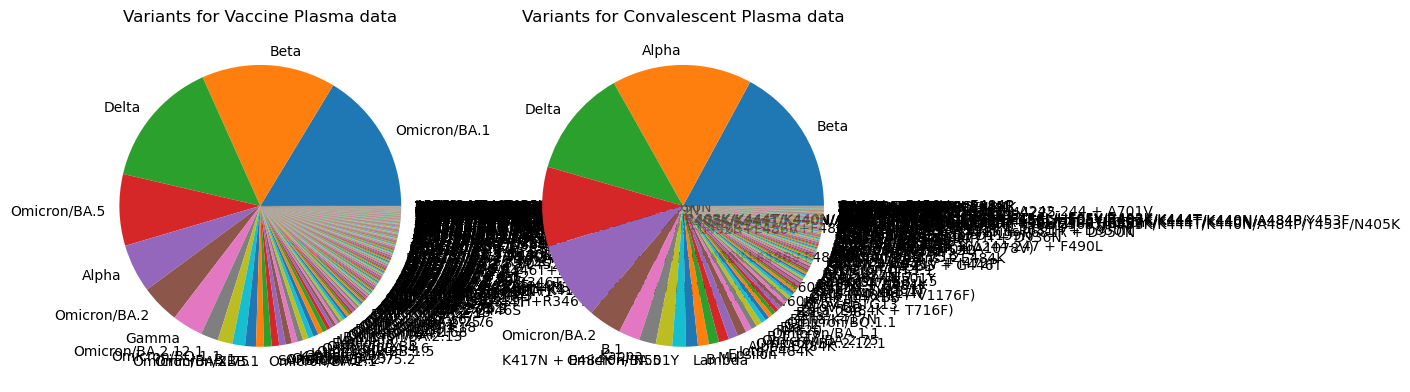

In [4]:
# What are the different controls?
vpvariants = vp[['Variant', '# Results']].groupby('Variant').agg('sum').sort_values(by='# Results', ascending=False).reset_index()
cpvariants = cp[['Variant', '# Results']].groupby('Variant').agg('sum').sort_values(by='# Results', ascending=False).reset_index()

fig, axes = plt.subplots(1, 2, figsize=(10, 5))
axes[0].pie(vpvariants['# Results'].values, labels=vpvariants['Variant'].values);
axes[0].set_title('Variants for Vaccine Plasma data');
axes[1].pie(cpvariants['# Results'].values, labels=cpvariants['Variant'].values);
axes[1].set_title('Variants for Convalescent Plasma data');

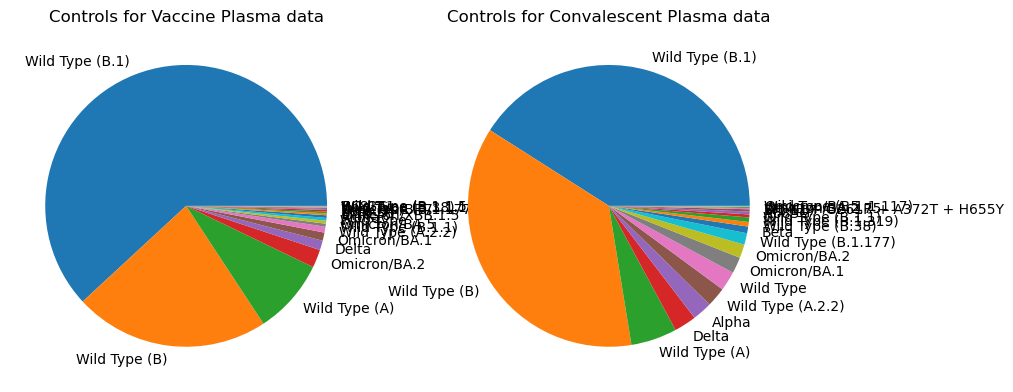

In [5]:
# What are the different controls?
vpcontrols = vp[['Control', '# Results']].groupby('Control').agg('sum').sort_values(by='# Results', ascending=False).reset_index()
cpcontrols = cp[['Control', '# Results']].groupby('Control').agg('sum').sort_values(by='# Results', ascending=False).reset_index()

fig, axes = plt.subplots(1, 2, figsize=(10, 5))
axes[0].pie(vpcontrols['# Results'].values, labels=vpcontrols['Control'].values);
axes[0].set_title('Controls for Vaccine Plasma data');
axes[1].pie(cpcontrols['# Results'].values, labels=cpcontrols['Control'].values);
axes[1].set_title('Controls for Convalescent Plasma data');

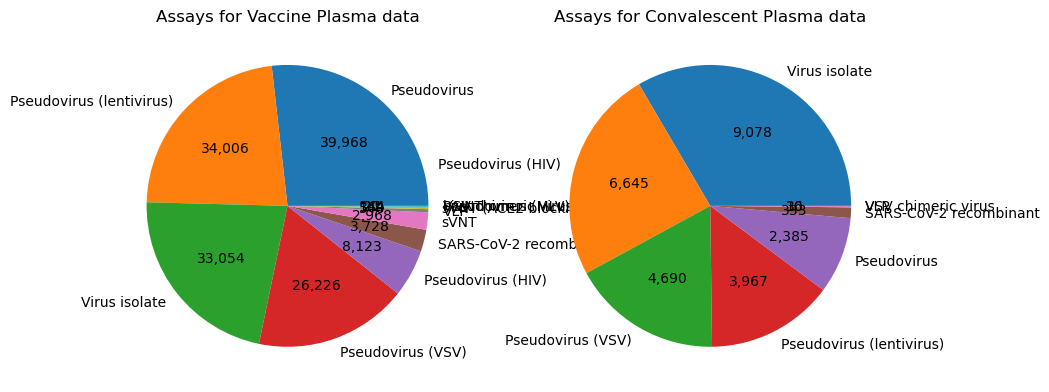

In [6]:
# What are the different assays?
vpcontrols = vp[['Assay', '# Results']].groupby('Assay').agg('sum').sort_values(by='# Results', ascending=False).reset_index()
cpcontrols = cp[['Assay', '# Results']].groupby('Assay').agg('sum').sort_values(by='# Results', ascending=False).reset_index()

def count(pct, data):
    total_count = data['# Results'].sum()
    x = int(np.round(pct/100*total_count))
    return '{:,.0f}'.format(x)

fig, axes = plt.subplots(1, 2, figsize=(10, 5))
axes[0].pie(vpcontrols['# Results'].values, labels=vpcontrols['Assay'].values, autopct=lambda pct: count(pct, vpcontrols));
axes[0].set_title('Assays for Vaccine Plasma data');
axes[1].pie(cpcontrols['# Results'].values, labels=cpcontrols['Assay'].values, autopct=lambda pct: count(pct, cpcontrols));
axes[1].set_title('Assays for Convalescent Plasma data');

In [7]:
cp.columns

Index(['Reference', 'Reference: DOI', 'Assay', 'Section', 'Infection (CP)',
       'Months', 'Host', 'Control', 'Control: NT50 Cmp',
       'Control: NT50 GeoMean', 'Control: NT50 GSD', 'Mutations',
       'Mutation: Pos', '# Results', 'Potency: NT50 Cmp',
       'Potency: NT50 GeoMean', 'Potency: NT50 GSD', 'Fold Reduction: Cmp',
       'Fold Reduction: Median', 'Fold Reduction: IQR25',
       'Fold Reduction: IQR75', 'Data Availability', 'Variant'],
      dtype='object')

/var/folders/lj/kt2p_lkd6rbg0tlbf4ykgqrm0000gq/T/ipykernel_76034/3776861278.py:29: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=70)
/var/folders/lj/kt2p_lkd6rbg0tlbf4ykgqrm0000gq/T/ipykernel_76034/3776861278.py:29: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=70)
/var/folders/lj/kt2p_lkd6rbg0tlbf4ykgqrm0000gq/T/ipykernel_76034/3776861278.py:29: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=70)
/var/folders/lj/kt2p_lkd6rbg0tlbf4ykgqrm0000gq/T/ipykernel_76034/3776861278.py:29: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a Fi

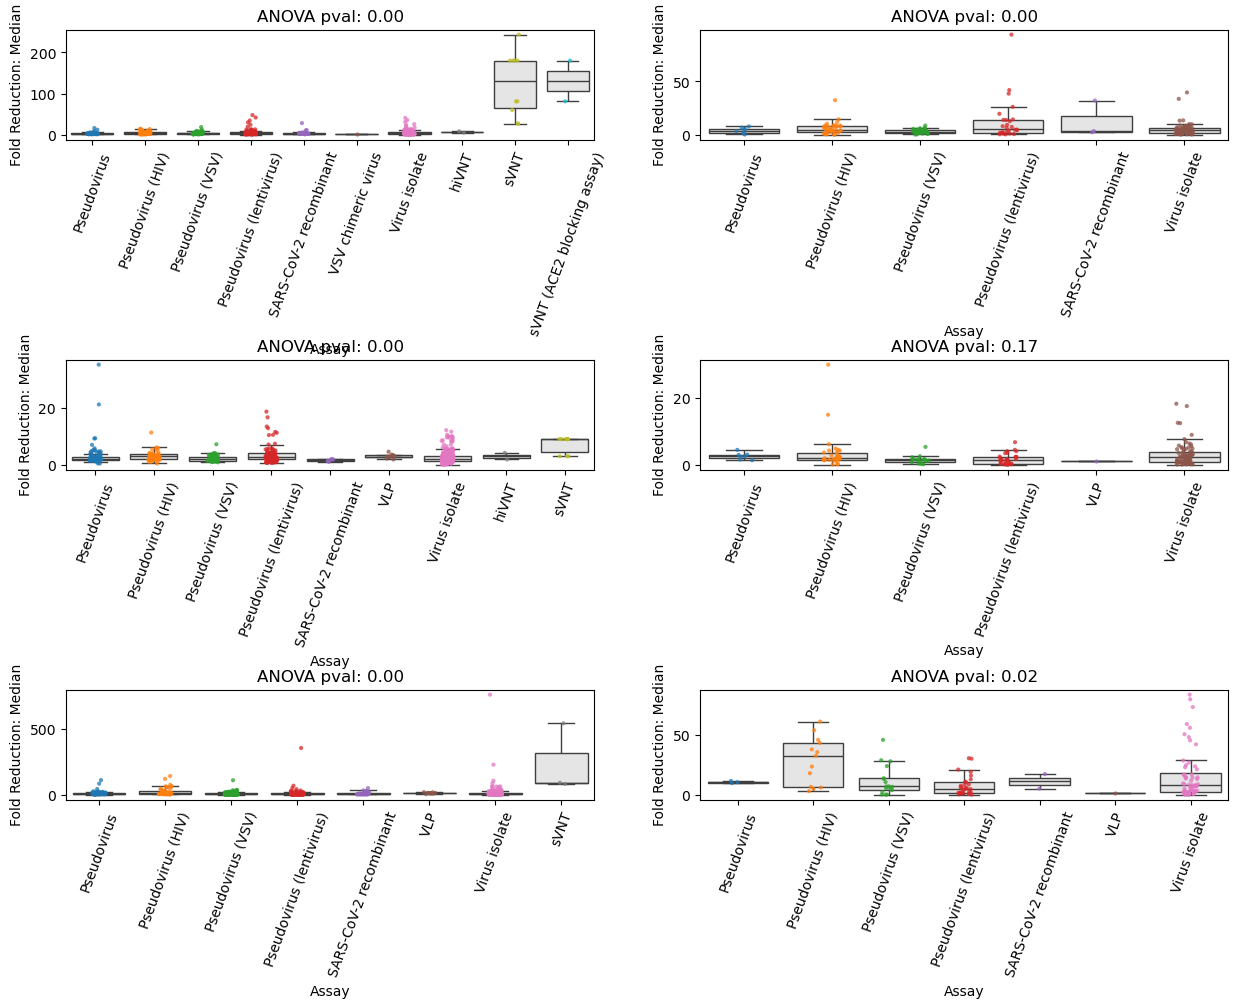

In [8]:
# Does assay matter?
fig, axes = plt.subplots(3,2, figsize=(15,10))
variant_subset = ['Beta', 'Delta', 'Omicron/BA.1']
axes = axes.flatten()
for i, ax in enumerate(axes):
    variant = variant_subset[i//2]
    df = vp if i%2==0 else cp
    temp_df=df[df['Variant']==variant].sort_values(by='Assay')
    sns.boxplot(x='Assay',
                y='Fold Reduction: Median',
                # hue='Assay',
                data=temp_df,
                showfliers=False,
                boxprops={"facecolor": (0, 0, 0, 0.1)},
                ax=ax)
    sns.stripplot(x='Assay',
                y='Fold Reduction: Median',
                hue='Assay',
                data=temp_df,
                jitter=True,
                alpha=0.75,
                s=3,
                ax=ax)
    # ax.legend().set_visible(False)
    result = temp_df.groupby('Assay')['Fold Reduction: Median'].apply(list).reset_index()['Fold Reduction: Median'].values
    if len(result)>1:
        stat, p = f_oneway(*result)
        ax.set_title(f'ANOVA pval: {p:.2f}')
    ax.set_xticklabels(ax.get_xticklabels(), rotation=70)
fig.subplots_adjust(hspace=2)

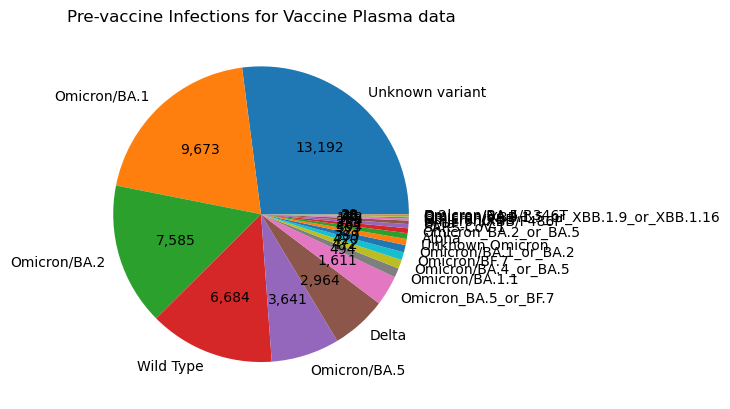

In [9]:
# What are the pre-vaccine infections?
vp_infections = vp[['Pre-vaccine Infection', '# Results']].groupby('Pre-vaccine Infection').agg('sum').sort_values(by='# Results', ascending=False).reset_index()

def count(pct, data):
    total_count = data['# Results'].sum()
    x = int(np.round(pct/100*total_count))
    return '{:,.0f}'.format(x)
    

fig, ax = plt.subplots()
ax.pie(vp_infections['# Results'].values, 
       labels=vp_infections['Pre-vaccine Infection'].values, 
       autopct=lambda pct: count(pct, vp_infections)
      )
ax.set_title('Pre-vaccine Infections for Vaccine Plasma data');

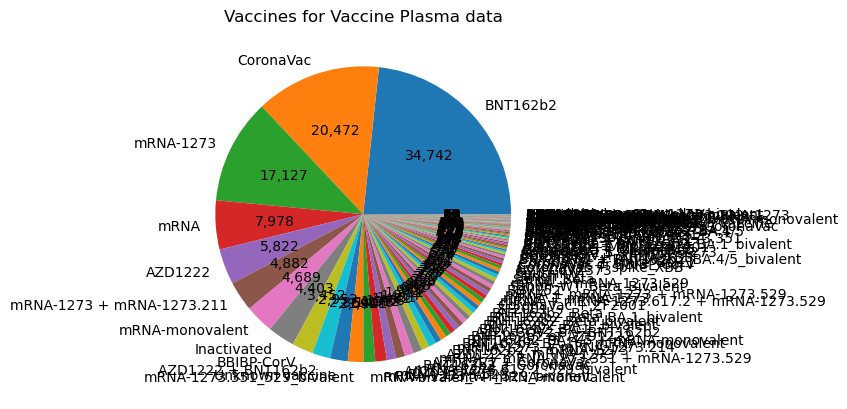

In [10]:
# What are the vaccines?
vp_vaccines = vp[['Vaccine', '# Results']].groupby('Vaccine').agg('sum').sort_values(by='# Results', ascending=False).reset_index()

def count(pct, data):
    total_count = data['# Results'].sum()
    x = int(np.round(pct/100*total_count))
    return '{:,.0f}'.format(x)
    

fig, ax = plt.subplots()
ax.pie(vp_vaccines['# Results'].values, 
       labels=vp_vaccines['Vaccine'].values, 
       autopct=lambda pct: count(pct, vp_vaccines)
      )
ax.set_title('Vaccines for Vaccine Plasma data');

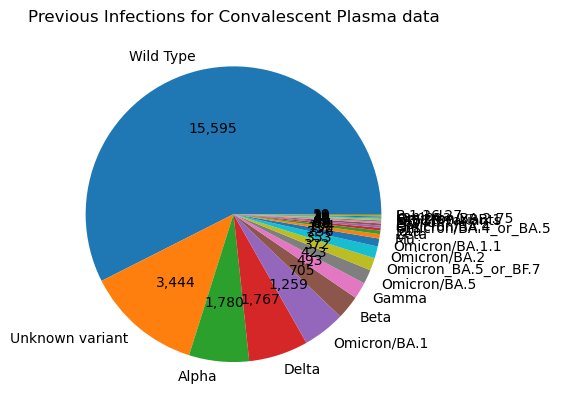

In [11]:
# What are the CP infections?
cp_infections = cp[['Infection (CP)', '# Results']].groupby('Infection (CP)').agg('sum').sort_values(by='# Results', ascending=False).reset_index()

def count(pct, data):
    total_count = data['# Results'].sum()
    x = int(np.round(pct/100*total_count))
    return '{:,.0f}'.format(x)
    

fig, ax = plt.subplots()
ax.pie(cp_infections['# Results'].values, 
       labels=cp_infections['Infection (CP)'].values, 
       autopct=lambda pct: count(pct, cp_infections)
      )
ax.set_title('Previous Infections for Convalescent Plasma data');

In [12]:
# Explore relationship between # shots and months; do these need to be incorporated as hierarchical layers?
vax_pools = vp.groupby(['Vaccine', '# Shots', 'Months']).agg('count')['Reference'].reset_index().sort_values(by=['Vaccine', '# Shots', 'Months'])
vax_pools.groupby(['Vaccine', 'Months']).agg({'# Shots':'count', 'Reference':'sum'}).reset_index()

,Vaccine,Months,# Shots,Reference
0,AZD1222,1m,3,138
1,AZD1222,2-6m,3,61
2,AZD1222,≥6m,2,21
3,AZD1222 + AZD2816,1m,2,4
4,AZD1222 + AZD2816,2-6m,1,3
...,...,...,...,...
166,mRNA_XBB,1m,1,3
167,spike_BA5,1m,1,2
168,spike_BQ11,1m,1,3
169,spike_WT,2-6m,1,3


In [13]:
vax_pools.groupby('Vaccine').agg('count')

,# Shots,Months,Reference
Vaccine,,,
AZD1222,8,8,8
AZD1222 + AZD2816,3,3,3
AZD1222 + BBV152,1,1,1
AZD1222 + BNT162b2,4,4,4
AZD1222 + BNT162b2 + CoronaVac,1,1,1
...,...,...,...
mRNA_XBB,1,1,1
spike_BA5,1,1,1
spike_BQ11,1,1,1


This shows that vaccine is likely not sufficient for a pool. I may want to consider # Shots and/or Months as well when creating the pools.

Based on this data, I think we should vp data when there has been no previous infections, since this will give us the most uniform group within each vaccine category. 

For cp data, we should keep only cases where WT was the previous infection. I do not have confidence that the other previous infection categories refer to a single variant; there may be variation within "Alpha", e.g.

Let's keep all vaccine types, and retain a column describing Assay because it might become useful later.

In [14]:
vp['Serum type']='Vaccine plasma'
cp['Serum type']='Convalescent plasma'
final_df = pd.concat([
    vp[vp['Pre-vaccine Infection']=='None'][['Mutations', 'Fold Reduction: Median', 'Assay', 'Serum type']],
    cp[cp['Infection (CP)']=='Wild Type'][['Mutations', 'Fold Reduction: Median', 'Assay', 'Serum type']]
]).reset_index(drop=True)
final_df

,Mutations,Fold Reduction: Median,Assay,Serum type
0,L5F,1.1,Pseudovirus (VSV),Convalescent plasma
1,L8V,1.3,Pseudovirus (VSV),Convalescent plasma
2,L8W,0.9,Pseudovirus (VSV),Convalescent plasma
3,B.1.1.63 (S12F),1.0,Virus isolate,Convalescent plasma
4,S12P,3.3,Pseudovirus (VSV),Convalescent plasma
...,...,...,...,...
893,(WT),1.9,Pseudovirus,Convalescent plasma
894,(WT),0.7,Pseudovirus (lentivirus),Convalescent plasma
895,(WT),1.0,Virus isolate,Convalescent plasma
896,(WT),1.0,Virus isolate,Convalescent plasma


In [15]:
vax_pools.groupby('Vaccine')['Reference'].agg('sum').index

Index(['AZD1222', 'AZD1222 + AZD2816', 'AZD1222 + BBV152',
       'AZD1222 + BNT162b2', 'AZD1222 + BNT162b2 + CoronaVac',
       'AZD1222 + CoronaVac', 'AZD1222 + CoronaVac + mRNA-1273',
       'AZD1222 + MVC-COV1901', 'AZD1222 + NVX-CoV2373', 'AZD1222 + Sputnik V',
       ...
       'mRNA_BQ11', 'mRNA_WT', 'mRNA_WT + spike_BA5', 'mRNA_WT + spike_BQ11',
       'mRNA_WT + spike_XBB', 'mRNA_XBB', 'spike_BA5', 'spike_BQ11',
       'spike_WT', 'spike_XBB'],
      dtype='object', name='Vaccine', length=113)

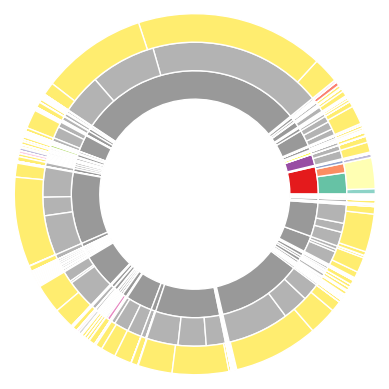

In [16]:
fig, ax = plt.subplots(subplot_kw=dict(projection="polar"))

size = 0.3

total_n_refs = vax_pools['Reference'].sum()

vaccine_ring = vax_pools.groupby('Vaccine')['Reference'].agg('sum').values
months_ring = vax_pools.groupby(['Vaccine', 'Months'])['Reference'].agg('sum').reset_index().pivot(index='Vaccine', columns='Months').fillna(0).values
shots_ring = vax_pools.groupby(['Vaccine', '# Shots'])['Reference'].agg('sum').reset_index().pivot(index='Vaccine', columns='# Shots').fillna(0).values

vaccine_ring_valsnorm = vaccine_ring / total_n_refs*2*np.pi
months_ring_valsnorm = months_ring / total_n_refs*2*np.pi
shots_ring_valsnorm = shots_ring / total_n_refs*2*np.pi

vaccine_ring_valsleft = np.cumsum(np.append(0, vaccine_ring_valsnorm.flatten()[:-1])).reshape(vaccine_ring.shape)
months_ring_valsleft = np.cumsum(np.append(0, months_ring_valsnorm.flatten()[:-1])).reshape(months_ring.shape)
shots_ring_valsleft = np.cumsum(np.append(0, shots_ring_valsnorm.flatten()[:-1])).reshape(shots_ring.shape)

ax.bar(x=vaccine_ring_valsleft,
       width=vaccine_ring_valsnorm, bottom=1, height=size,
       color=plt.colormaps["Set1"](range(len(vaccine_ring))), edgecolor='w', linewidth=1, align="edge")

ax.bar(x=months_ring_valsleft.flatten(),
       width=months_ring_valsnorm.flatten(), bottom=1+size, height=size,
       color=plt.colormaps["Set2"](range(len(months_ring))), edgecolor='w', linewidth=1, align="edge")

ax.bar(x=shots_ring_valsleft.flatten(),
       width=shots_ring_valsnorm.flatten(), bottom=1+2*size, height=size,
       color=plt.colormaps["Set3"](range(len(months_ring))), edgecolor='w', linewidth=1, align="edge")

ax.set_axis_off()
plt.show()

In [17]:
vax_pools.groupby(['Vaccine', 'Months'])['Reference'].agg('sum').reset_index().pivot(index='Vaccine', columns='Months').fillna(0)

Reference            
Months                                1m  2-6m   ≥6m
Vaccine                                             
AZD1222                            138.0  61.0  21.0
AZD1222 + AZD2816                    4.0   3.0   0.0
AZD1222 + BBV152                     3.0   0.0   0.0
AZD1222 + BNT162b2                  55.0  34.0   0.0
AZD1222 + BNT162b2 + CoronaVac       2.0   0.0   0.0
...                                  ...   ...   ...
mRNA_XBB                             3.0   0.0   0.0
spike_BA5                            2.0   0.0   0.0
spike_BQ11                           3.0   0.0   0.0
spike_WT                             0.0   3.0   0.0
spike_XBB                            3.0   0.0   0.0

[113 rows x 3 columns]

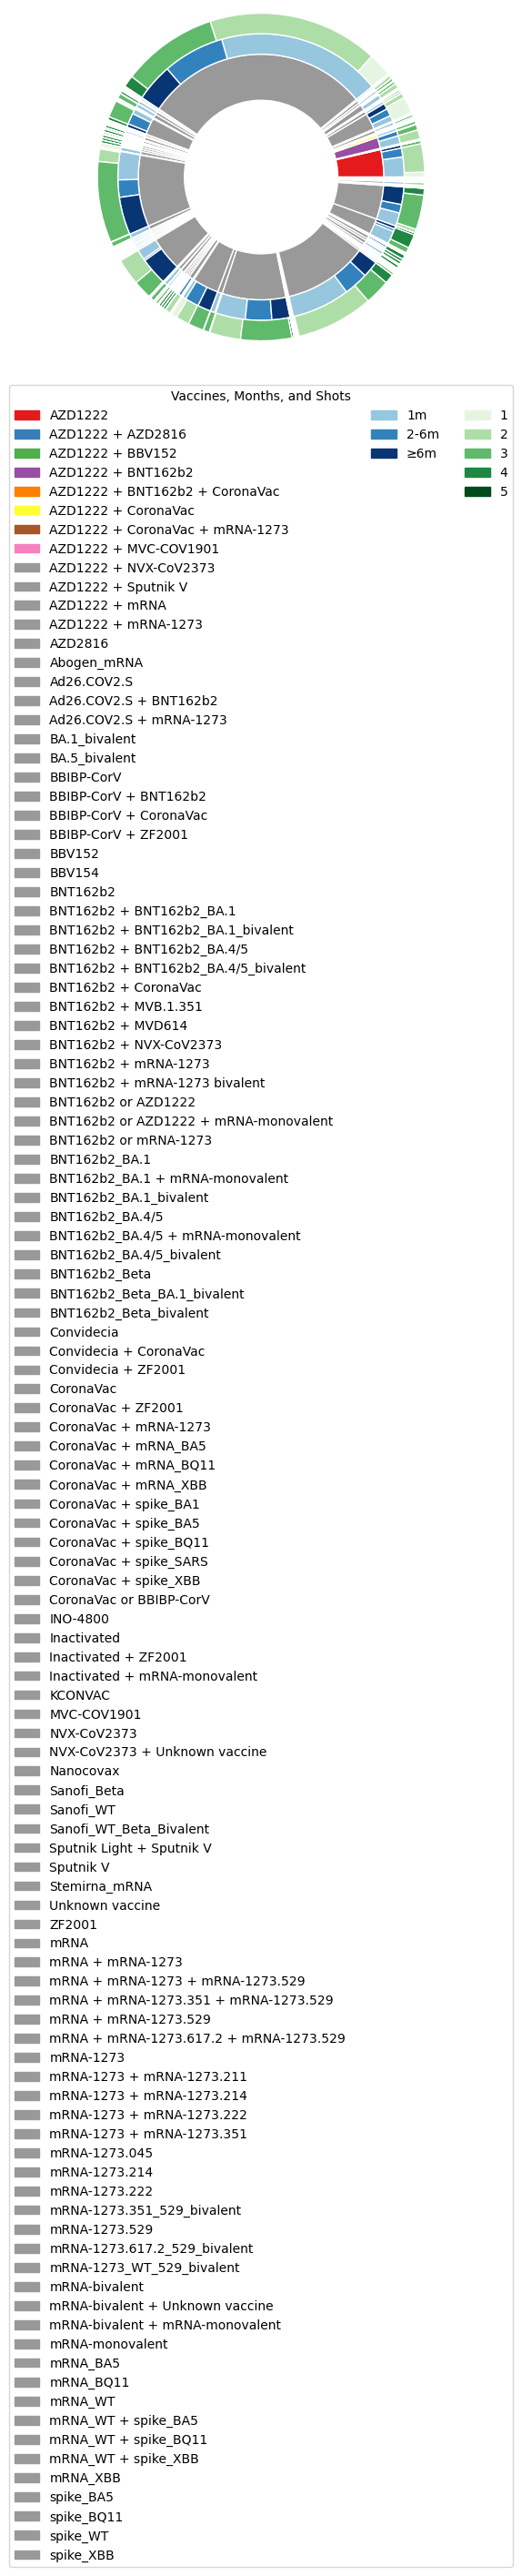

In [18]:
fig, ax = plt.subplots(subplot_kw=dict(projection="polar"))

size = 0.2

total_n_refs = vax_pools['Reference'].sum()

vaccine_ring = vax_pools.groupby('Vaccine')['Reference'].agg('sum')
vaccine_ring_valsnorm = vaccine_ring.values / total_n_refs*2*np.pi
vaccine_ring_valsleft = np.cumsum(np.append(0, vaccine_ring_valsnorm.flatten()[:-1])).reshape(vaccine_ring.shape)
vaccine_ring_labels = vaccine_ring.index.tolist()
vaccine_ring_colors = plt.colormaps["Set1"](range(len(vaccine_ring)))

months_ring = vax_pools.groupby(['Vaccine', 'Months'])['Reference'].agg('sum').reset_index().pivot(index='Vaccine', columns='Months').fillna(0)
months_ring_valsnorm = months_ring.values / total_n_refs*2*np.pi
months_ring_valsleft = np.cumsum(np.append(0, months_ring_valsnorm.flatten()[:-1])).reshape(months_ring.shape)
months_ring_labels = months_ring.columns.droplevel(None).tolist()
months_ring_colors = plt.colormaps["Blues"](np.array(100+LabelEncoder().fit_transform(months_ring_labels)*(250-100)/(len(months_ring_labels)-1), dtype=int))
months_ring_labels_scaled = months_ring_labels*len(months_ring)
months_ring_colors_scaled = np.tile(months_ring_colors, np.array([len(months_ring),1]))

shots_ring = vax_pools.groupby(['Vaccine', '# Shots'])['Reference'].agg('sum').reset_index().pivot(index='Vaccine', columns='# Shots').fillna(0)
shots_ring_valsnorm = shots_ring.values / total_n_refs*2*np.pi
shots_ring_valsleft = np.cumsum(np.append(0, shots_ring_valsnorm.flatten()[:-1])).reshape(shots_ring.shape)
shots_ring_labels = shots_ring.columns.droplevel(None).tolist()
shots_ring_colors = plt.colormaps["Greens"](np.array(30+LabelEncoder().fit_transform(shots_ring_labels)*(250-30)/(len(shots_ring_labels)-1), dtype=int))
shots_ring_labels_scaled = shots_ring_labels*len(shots_ring)
shots_ring_colors_scaled = np.tile(shots_ring_colors, np.array([len(shots_ring),1]))

ax.bar(x=vaccine_ring_valsleft,
       width=vaccine_ring_valsnorm, bottom=0.75, height=0.25+size,
       color=vaccine_ring_colors, edgecolor='w', linewidth=1, align="edge")

ax.bar(x=months_ring_valsleft.flatten(),
       width=months_ring_valsnorm.flatten(), bottom=1+size, height=size,
       color=months_ring_colors_scaled, edgecolor='w', linewidth=1, align="edge")

ax.bar(x=shots_ring_valsleft.flatten(),
       width=shots_ring_valsnorm.flatten(), bottom=1+2*size, height=size,
       color=shots_ring_colors_scaled, edgecolor='w', linewidth=1, align="edge")

ax.set_axis_off()

# Create patches for each group
vaccine_patches = [Patch(color=color, label=label) for color, label in zip(vaccine_ring_colors, vaccine_ring_labels)]
months_patches = [Patch(color=color, label=label) for color, label in zip(months_ring_colors, months_ring_labels)]
shots_patches = [Patch(color=color, label=label) for color, label in zip(shots_ring_colors, shots_ring_labels)]
# Pad the shorter lists with empty patches
empty_patch = Patch(color='none', label='')
# Determine the maximum length of the columns
max_len = max(len(vaccine_patches), len(months_patches), len(shots_patches))
vaccine_patches += [empty_patch] * (max_len - len(vaccine_patches))
months_patches += [empty_patch] * (max_len - len(months_patches))
shots_patches += [empty_patch] * (max_len - len(shots_patches))

# Create the legend with 3 columns
all_patches = vaccine_patches + months_patches + shots_patches
ax.legend(handles=all_patches, loc='upper center', bbox_to_anchor=(0.5, -0.1),
          ncol=3, title="Vaccines, Months, and Shots")

plt.show()